<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/Weibull.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import weibull_min

In [ ]:
# 1. Lectura de excel (base de datos)

# Cambia "datos.xlsx" por el nombre real de tu archivo
df = pd.read_excel("Mangueras LTA - Fallas.xlsx")

# Mostrar las primeras filas
df.head()

,Unnamed: 0,Unnamed: 1,Código Material,Fecha Entrega OC,equipo,Horas duracion
0,NaN,NaN,CM438094800,2021-12-11,CA 3174,1845.0
1,NaN,NaN,CM438094800,2022-05-31,CA 3174,3505.5
2,NaN,NaN,CM438094800,2022-08-15,CA 3198,4374.0
3,NaN,NaN,CM438094800,2022-08-15,CA 3177,6300.0
4,NaN,NaN,CM438094800,2022-09-17,CA 3167,8265.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        0 non-null      float64       
 1   Unnamed: 1        0 non-null      float64       
 2   Código Material   45 non-null     object        
 3   Fecha Entrega OC  45 non-null     datetime64[ns]
 4   equipo            45 non-null     object        
 5   Horas duracion    35 non-null     float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 2.2+ KB


In [ ]:
# 2. Limpieza de datos

# Elimina columnas que estén completamente vacías
# axis=1 → significa columnas.
# how="all" → elimina solo si toda la columna está vacía.
df = df.dropna(axis=1, how="all")

In [ ]:
#3. Asegurar que la fecha este en formato correcto y filtrado de rangos

# Asegurar que la columna de fecha sea datetime
df["Fecha Entrega OC"] = pd.to_datetime(df["Fecha Entrega OC"], errors="coerce")

#Si solo quieres borrar filas con nulos en ciertas columnas (por ejemplo "duracion")
df = df.dropna(subset=["Horas duracion"])

# Filtrar solo desde 2024 en adelante
df = df[df["Fecha Entrega OC"] >= "2023-01-01"]

In [ ]:
df.head()


,Código Material,Fecha Entrega OC,equipo,Horas duracion
11,CM438094800,2023-01-08,CA 3178,9504.0
12,CM438094800,2023-01-14,CA 3170,10404.0
14,CM438094800,2023-02-08,CA 3168,11424.0
15,CM438094800,2023-02-18,CA 3198,3833.5
16,CM438094800,2023-04-17,CA 3170,1906.5


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 11 to 44
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Código Material   25 non-null     object        
 1   Fecha Entrega OC  25 non-null     datetime64[ns]
 2   equipo            25 non-null     object        
 3   Horas duracion    25 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 1000.0+ bytes


In [ ]:
# Gráfico de caja (bigotes)
# Extraer la columna de horas
horas = df["Horas duracion"].dropna()

# Calcular percentiles
Q1 = np.percentile(horas, 25)
Q2 = np.percentile(horas, 50)  # Mediana
Q3 = np.percentile(horas, 75)
IQR = Q3 - Q1

# Límites para outliers
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

# Detectar outliers
outliers = horas[(horas < limite_inf) | (horas > limite_sup)]

# Imprimir resultados
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q2 (Mediana, 50%): {Q2:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inf:.2f}")
print(f"Límite superior: {limite_sup:.2f}")
print("Outliers encontrados:")
print(outliers.values)


Q1 (25%): 4161.50
Q2 (Mediana, 50%): 8260.00
Q3 (75%): 10909.00
IQR: 6747.50
Límite inferior: -5959.75
Límite superior: 21030.25
Outliers encontrados:
[]


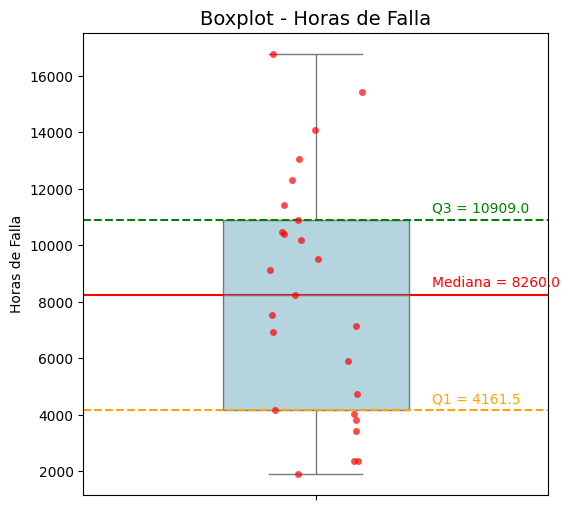

In [ ]:
# 📌 Gráfico boxplot + puntos individuales
plt.figure(figsize=(6, 6))
sns.boxplot(y=df["Horas duracion"], color="lightblue", width=0.4)
sns.stripplot(y=df["Horas duracion"], color="red", size=5, jitter=True, alpha=0.7)

# Agregar líneas de referencia
plt.axhline(Q1, color="orange", linestyle="--", label=f"Q1 = {Q1:.1f}")
plt.axhline(Q2, color="red", linestyle="-", label=f"Mediana = {Q2:.1f}")
plt.axhline(Q3, color="green", linestyle="--", label=f"Q3 = {Q3:.1f}")

# Anotaciones en el gráfico
plt.text(0.25, Q1+400, f"Q1 = {Q1:.1f}", color="orange", va="center")
plt.text(0.25, Q2+400, f"Mediana = {Q2:.1f}", color="red", va="center")
plt.text(0.25, Q3+400, f"Q3 = {Q3:.1f}", color="green", va="center")

plt.title("Boxplot - Horas de Falla", fontsize=14)
plt.ylabel("Horas de Falla")
plt.show()

Horas promedio de falla: 8249.20
Parámetro forma (β): 2.09
Parámetro escala (η): 9329.60
Horas cuando la confiabilidad es 70%: 5695.77 horas
Horas cuando la confiabilidad es 60%: 6764.32 horas


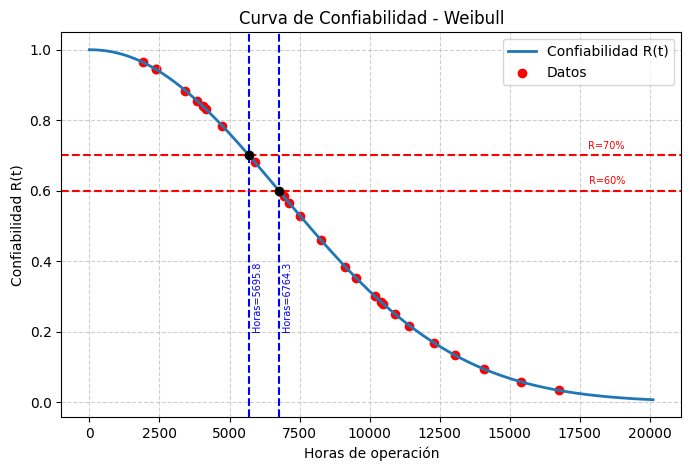

In [ ]:
#Grafica de weibull



# Datos de fallas (horas)
horas = df["Horas duracion"].dropna().values  # Convertir a numpy array y eliminar nulos
#-----------------------------------------------------------------

# Calcular estadísticas básicas
promedio_falla = np.mean(horas)
print(f"Horas promedio de falla: {promedio_falla:.2f}")
#-----------------------------------------------------------------
# Ajuste de distribución Weibull
# Ajustar parámetros de Weibull (forma, loc, escala)
forma, loc, escala = weibull_min.fit(horas, floc=0)

print(f"Parámetro forma (β): {forma:.2f}")
print(f"Parámetro escala (η): {escala:.2f}")

#-----------------------------------------------------------------
#Graficar función de confiabilidad (R(t))   R(t)=e−(t/η)β

# Rango de horas para graficar
t = np.linspace(0, max(horas)*1.2, 100)

# Función de confiabilidad Weibull
R_t = np.exp(- (t/escala)**forma)

#Curva de confiabilidad
plt.figure(figsize=(8,5))
plt.plot(t, R_t, label="Confiabilidad R(t)", linewidth=2)
plt.scatter(horas, np.exp(-(horas/escala)**forma), color="red", label="Datos")

#________________________________________________________________________________________________________________
#Calcular las horas para R=0.7

R_obj70 = 0.7  # 70% de confiabilidad

t_obj70 = escala * (-np.log(R_obj70))**(1/forma)
print(f"Horas cuando la confiabilidad es 70%: {t_obj70:.2f} horas")


# Punto objetivo
#R=confiabilidad
plt.axhline(y=R_obj70, color="red", linestyle="--")
plt.text(t[-1]*0.95, R_obj70+0.02, "R=70%", color="red", ha="right", fontsize=7)
#Horas
plt.axvline(x=t_obj70, color="blue", linestyle="--")
plt.text(t_obj70+100, 0.2, f"Horas={t_obj70:.1f}", color="blue", rotation=90, va="bottom", fontsize=7)

plt.scatter([t_obj70], [R_obj70], color="black", zorder=5)  # punto de cruce

#______________________________________________________________________________
#Calcular las horas para R=0.6

R_obj60 = 0.6  # 60% de confiabilidad

t_obj60 = escala * (-np.log(R_obj60))**(1/forma)
print(f"Horas cuando la confiabilidad es 60%: {t_obj60:.2f} horas")

# Punto objetivo
#R=confiabilidad
plt.axhline(y=R_obj60, color="red", linestyle="--")
plt.text(t[-1]*0.95, R_obj60+0.02, "R=60%", color="red", ha="right", fontsize=7)
#Horas
plt.axvline(x=t_obj60, color="blue", linestyle="--")
plt.text(t_obj60+100, 0.2, f"Horas={t_obj60:.1f}", color="blue", rotation=90, va="bottom", fontsize=7)

plt.scatter([t_obj60], [R_obj60], color="black", zorder=5)  # punto de cruce






plt.title("Curva de Confiabilidad - Weibull")
plt.xlabel("Horas de operación")
plt.ylabel("Confiabilidad R(t)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()




#Paso 6. Interpretación (para tu informe o tesis/mina)

# β (forma) → Si β < 1 hay fallas tempranas, si β ≈ 1 son aleatorias, si β > 1 hay desgaste.
# η (escala) → Horas donde el 63.2% de las mangueras han fallado (vida característica).
# MTTF (promedio) → Tiempo esperado de falla

In [ ]:
# Calcular %Confiabilidad y las horas respectivas

# 🔹 Niveles de confiabilidad deseados
niveles_R = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4]

# 🔹 Cálculo de horas de cambio preventivo para cada confiabilidad
horas_cambio = []
for R in niveles_R:
    t = escala * (-np.log(R))**(1/forma)
    horas_cambio.append(t)

# 🔹 Crear tabla con resultados
df_resultados = pd.DataFrame({
    "Confiabilidad objetivo (R)": niveles_R,
    "Probabilidad de falla (%)": [(1-R)*100 for R in niveles_R],
    "Horas de cambio preventivo": [round(h,2) for h in horas_cambio]
})

# Mostrar tabla
print("\nHoras de cambio preventivo según curva Weibull:")
print(df_resultados)

# Exportar a Excel
df_resultados.to_excel("weibull mangueras LTA.xlsx", index=False)  # index=False evita que guarde la columna de índices


Horas de cambio preventivo según curva Weibull:
   Confiabilidad objetivo (R)  Probabilidad de falla (%)  \
0                         0.9                       10.0   
1                         0.8                       20.0   
2                         0.7                       30.0   
3                         0.6                       40.0   
4                         0.5                       50.0   
5                         0.4                       60.0   

   Horas de cambio preventivo  
0                     3177.28  
1                     4550.45  
2                     5695.77  
3                     6764.32  
4                     7828.38  
5                     8947.25  


In [ ]:
print(df["Fecha Entrega OC"].values)

['2023-01-08T00:00:00.000000000' '2023-01-14T00:00:00.000000000'
 '2023-02-08T00:00:00.000000000' '2023-02-18T00:00:00.000000000'
 '2023-04-17T00:00:00.000000000' '2023-05-13T00:00:00.000000000'
 '2023-06-13T00:00:00.000000000' '2023-07-10T00:00:00.000000000'
 '2023-08-10T00:00:00.000000000' '2023-08-22T00:00:00.000000000'
 '2023-09-24T00:00:00.000000000' '2023-10-10T00:00:00.000000000'
 '2023-10-27T00:00:00.000000000' '2024-02-29T00:00:00.000000000'
 '2024-04-09T00:00:00.000000000' '2024-06-14T00:00:00.000000000'
 '2024-06-21T00:00:00.000000000' '2024-07-06T00:00:00.000000000'
 '2025-12-24T00:00:00.000000000' '2025-03-15T00:00:00.000000000'
 '2025-05-03T00:00:00.000000000' '2025-06-07T00:00:00.000000000'
 '2025-06-21T00:00:00.000000000' '2025-07-19T00:00:00.000000000'
 '2025-08-16T00:00:00.000000000']
